In [2]:
!pip install pandas numpy scikit-learn matplotlib seaborn joblib

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import joblib

In [4]:
train_df = pd.read_csv(
    "/content/train.csv",
    header=None,
    names=["label","title","description"]
)

test_df = pd.read_csv(
    "/content/test.csv",
    header=None,
    names=["label","title","description"]
)

In [5]:
train_df["text"] = train_df["title"] + " " + train_df["description"]
test_df["text"] = test_df["title"] + " " + test_df["description"]

In [6]:
X_train = train_df["text"]
y_train = train_df["label"]

X_test = test_df["text"]
y_test = test_df["label"]

In [7]:
vectorizer = TfidfVectorizer(
    stop_words='english',
    max_features=50000
)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

In [8]:
model = LogisticRegression(
    max_iter=10000
)

model.fit(X_train_vec, y_train)

LogisticRegression(max_iter=10000)

In [9]:
y_pred = model.predict(X_test_vec)

In [10]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy =", accuracy)

Accuracy = 0.9148796211024866


In [11]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       0.93      0.90      0.92      1900
           2       0.96      0.98      0.97      1900
           3       0.89      0.88      0.88      1900
           4       0.89      0.90      0.89      1900
 Class Index       0.00      0.00      0.00         1

    accuracy                           0.91      7601
   macro avg       0.73      0.73      0.73      7601
weighted avg       0.91      0.91      0.91      7601



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


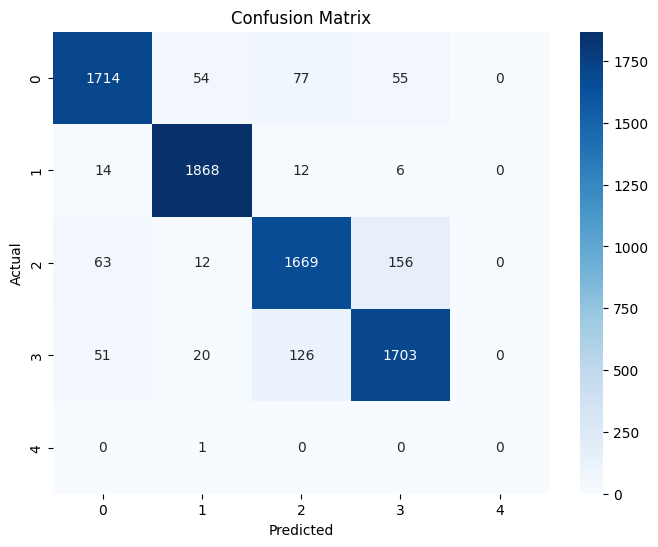

In [12]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [13]:
joblib.dump(model, "news_classifier.pkl")
joblib.dump(vectorizer, "tfidf_vectorizer.pkl")

print("Saved successfully")

Saved successfully
